# 🛒 Customer Churn Analysis using RFM

### 📊 End-to-End Data Analytics Project

This project analyzes customer behavior using **Python, SQL, and Power BI** to identify:

- Customer churn patterns  
- High-value customers  
- Revenue contribution by segment  
- Business insights for retention strategies  

---
💡 This project demonstrates end-to-end data analytics skills including data cleaning, feature engineering, segmentation, visualization, and SQL-based insights.

---

### 🚀 Tools Used
- Python (Pandas, Matplotlib)
- SQL (SQLite)
- Power BI (Dashboard)

---

### 🎯 Goal
To help businesses **reduce churn** and **increase customer lifetime value**

---

### 📈 Key Results
- Identified ~33% customer churn rate
- Loyal customers contribute majority of revenue
- High-value churn customers highlight revenue risk

In [160]:
import os
print(os.listdir('/content'))

['.config', 'online_retail.csv', 'rfm_data.csv', 'transactions_cleaned.csv', 'sample_data']


In [161]:
# pandas → for data manipulation
import pandas as pd

# matplotlib → for plotting charts
import matplotlib.pyplot as plt

# datetime → for date calculations (used in RFM)
import datetime as dt

# sqlite3 → to run SQL queries inside Python
import sqlite3

## Load Dataset
Load the online retail dataset and preview initial records.

In [162]:
# Load dataset (encoding used due to special characters)
df = pd.read_csv('/content/online_retail.csv', encoding='ISO-8859-1')

# Display first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Overview
Understand dataset size, structure, and missing values.

In [163]:
# Check dataset shape (rows, columns)
print("Shape:", df.shape)

# Check column names
print("\nColumns:", df.columns.tolist())

# Check missing values
df.isnull().sum()

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## Data Quality Checks
Identify common issues like missing IDs, cancellations, and invalid values.

In [164]:
# Missing customer IDs
print("Missing CustomerID:", df['CustomerID'].isnull().sum())

# Better naming "Negative Quantity" → "Returns / Invalid Quantity"
print("Negative Quantity:", (df['Quantity'] < 0).sum())

# Cancelled invoices (InvoiceNo starts with 'C')
print("Cancelled Invoices:", df['InvoiceNo'].astype(str).str.startswith('C').sum())

Missing CustomerID: 135080
Negative Quantity: 10624
Cancelled Invoices: 9288


In [165]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Min date:", df['InvoiceDate'].min())
print("Max date:", df['InvoiceDate'].max())

Min date: 2010-12-01 08:26:00
Max date: 2011-12-09 12:50:00


## Data Cleaning
Remove invalid records and prepare dataset for analysis.

In [166]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a copy of dataset
df_clean = df.copy()

# Remove missing customer IDs
df_clean = df_clean[df_clean['CustomerID'].notnull()]

# Remove cancelled invoices
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid quantities and prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Remove missing descriptions
df_clean = df_clean[df_clean['Description'].notnull()]

# Convert CustomerID to integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Create Revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Preview cleaned data
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [167]:
df_clean = df_clean.drop_duplicates()
print("Shape after dropping duplicates:", df_clean.shape)

Shape after dropping duplicates: (392692, 9)


## Cleaned Data Summary
Check dataset after cleaning.

In [168]:
print("Missing CustomerID after cleaning:", df_clean['CustomerID'].isnull().sum())
print("Negative Quantity after cleaning:", (df_clean['Quantity'] <= 0).sum())
print("Cancelled invoices after cleaning:", df_clean['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Missing Description after cleaning:", df_clean['Description'].isnull().sum())
print("Non-positive UnitPrice after cleaning:", (df_clean['UnitPrice'] <= 0).sum())

Missing CustomerID after cleaning: 0
Negative Quantity after cleaning: 0
Cancelled invoices after cleaning: 0
Missing Description after cleaning: 0
Non-positive UnitPrice after cleaning: 0


In [169]:
# Unique customers
print("Unique customers:", df_clean['CustomerID'].nunique())

# Total revenue
print("Total revenue:", round(df_clean['Revenue'].sum(), 2))

# Number of countries
print("Countries:", df_clean['Country'].nunique())

print("Unique invoices:", df_clean['InvoiceNo'].nunique())
print("Unique products:", df_clean['StockCode'].nunique())

Unique customers: 4338
Total revenue: 8887208.89
Countries: 37
Unique invoices: 18532
Unique products: 3665


## RFM Feature Engineering
Create Recency, Frequency, and Monetary metrics.

In [188]:
# Define reference date (latest date + 1 day)
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Group data to calculate RFM
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'Revenue': 'sum'  # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Preview RFM table
rfm.head()

# Create churn column (1 = churned, 0 = active)
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

# Define segmentation logic
def segment_customer(row):
    if row['Churn'] == 1 and row['Monetary'] > 2000:
        return 'High Value Churn'
    elif row['Churn'] == 1:
        return 'Churned'
    elif row['Recency'] < 30:
        return 'Active'
    elif row['Frequency'] > 5:
        return 'Loyal'
    else:
        return 'Regular'

# Apply segmentation
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Final preview
rfm.head()

,Recency,Frequency,Monetary,Churn,Segment
CustomerID,,,,,
12346,326,1,77183.60,1,High Value Churn
12347,2,7,4310.00,0,Active
12348,75,4,1797.24,0,Regular
12349,19,1,1757.55,0,Active
12350,310,1,334.40,1,Churned


In [171]:
print("RFM shape:", rfm.shape)
rfm.describe()

RFM shape: (4338, 3)


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [172]:
# Check recency distribution
rfm['Recency'].describe()

,Recency
count,4338.000000
mean,92.536422
std,100.014169
min,1.000000
25%,18.000000
50%,51.000000
75%,142.000000
max,374.000000


## Churn Calculation
Customers inactive for more than 90 days are considered churned.

In [173]:
# Create churn column (1 = churned, 0 = active)
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

# Calculate churn rate
churn_rate = rfm['Churn'].mean() * 100

print("Churn Rate:", round(churn_rate, 2), "%")

Churn Rate: 33.4 %


In [174]:
# Recency score (lower is better)
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4, 3, 2, 1],
    duplicates='drop'
)

# Frequency score (higher is better)
rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4],
    duplicates='drop'
)

# Monetary score (higher is better)
rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1, 2, 3, 4],
    duplicates='drop'
)

# Combine the three scores into one RFM score
rfm['RFM_score'] = (
    rfm['R_score'].astype(str)
    + rfm['F_score'].astype(str)
    + rfm['M_score'].astype(str)
)

rfm[['Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_score']].head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,4,114
12347,2,7,4310.00,4,4,4,444
12348,75,4,1797.24,2,3,4,234
12349,19,1,1757.55,3,1,4,314
12350,310,1,334.40,1,1,2,112


## Customer Segmentation
Categorize customers based on behavior.

In [175]:
# Define segmentation logic
def segment_customer(row):
    if row['Churn'] == 1 and row['Monetary'] > 2000:
        return 'High Value Churn'
    elif row['Churn'] == 1:
        return 'Churned'
    elif row['Recency'] < 30:
        return 'Active'
    elif row['Frequency'] > 5:
        return 'Loyal'
    else:
        return 'Regular'

# Apply segmentation
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Check segment distribution
rfm['Segment'].value_counts()

,count
Segment,
Active,1607
Churned,1379
Regular,1101
Loyal,181
High Value Churn,70


## Visualization
Analyze churn and customer behavior patterns.

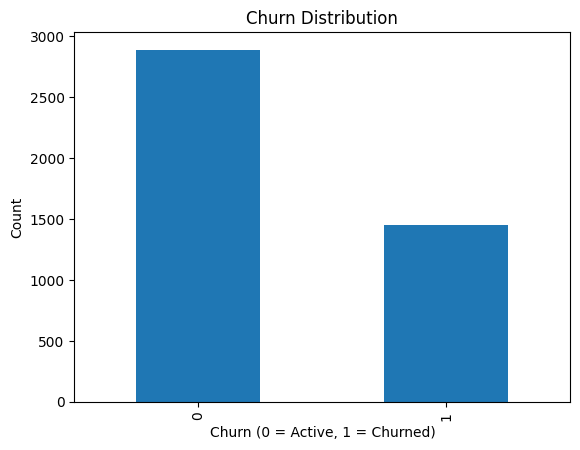

In [176]:
# Churn distribution
rfm['Churn'].value_counts().plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Active, 1 = Churned)")
plt.ylabel("Count")

plt.show()

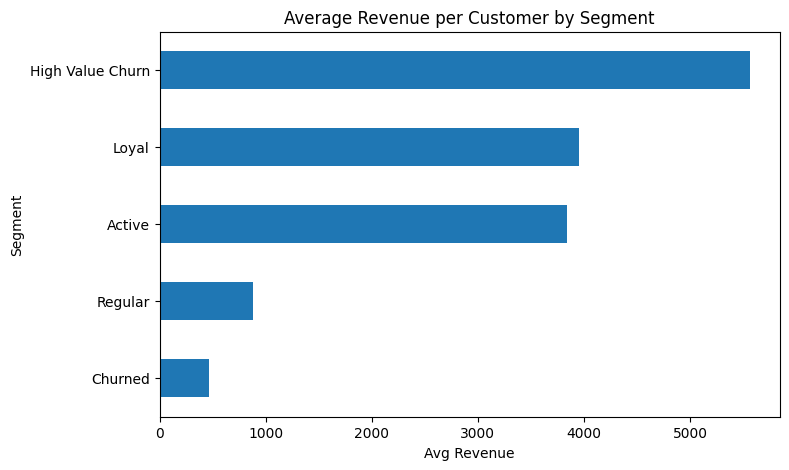

In [190]:
# Average revenue per segment
segment_avg = rfm.groupby('Segment')['Monetary'].mean().sort_values()

plt.figure(figsize=(8,5))

segment_avg.plot(kind='barh')

plt.title("Average Revenue per Customer by Segment")
plt.xlabel("Avg Revenue")
plt.ylabel("Segment")

plt.show()

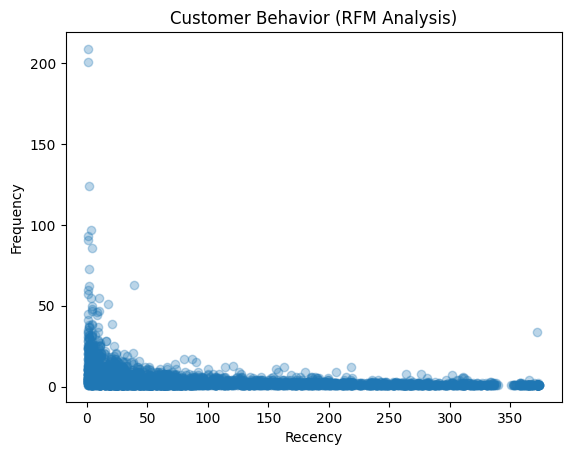

In [196]:
# Customer behavior scatter plot
plt.scatter(rfm['Recency'], rfm['Frequency'], alpha=0.3)

plt.title("Customer Behavior (RFM Analysis)")
plt.xlabel("Recency")
plt.ylabel("Frequency")

plt.show()

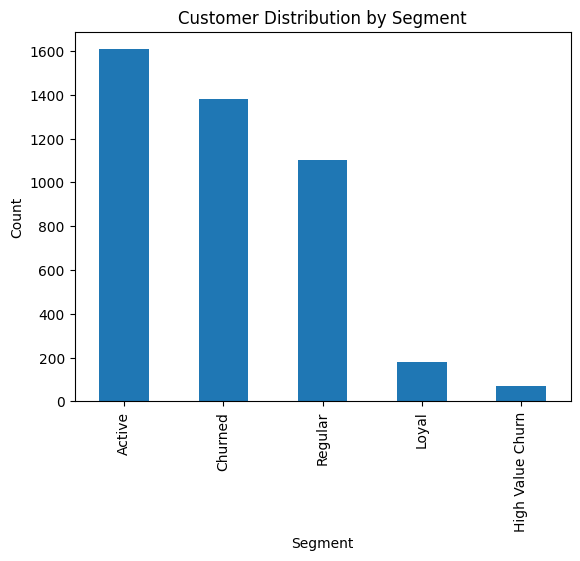

In [191]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

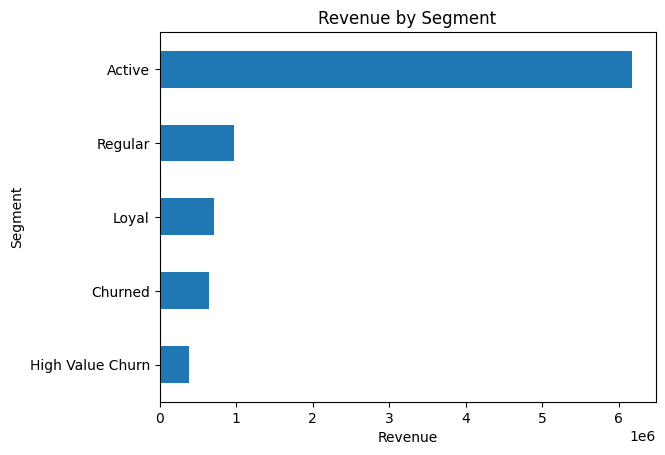

In [192]:
rfm.groupby('Segment')['Monetary'].sum().sort_values().plot(kind='barh')
plt.title("Revenue by Segment")
plt.xlabel("Revenue")
plt.ylabel("Segment")
plt.show()

## SQL Analysis
Perform SQL queries on cleaned dataset.

In [179]:
# Create in-memory SQL database
conn = sqlite3.connect(':memory:')

# Load data into SQL table
df_clean.to_sql('retail', conn, index=False)

392692

In [180]:
# Top customers by revenue
query1 = """
SELECT CustomerID, SUM(Revenue) AS total_revenue
FROM retail
GROUP BY CustomerID
ORDER BY total_revenue DESC
LIMIT 10;
"""

pd.read_sql(query1, conn)

,CustomerID,total_revenue
0,14646,280206.02
1,18102,259657.30
2,17450,194390.79
3,16446,168472.50
4,14911,143711.17
5,12415,124914.53
6,14156,117210.08
7,17511,91062.38
8,16029,80850.84
9,12346,77183.60


In [181]:
# Top countries by revenue
query2 = """
SELECT Country, SUM(Revenue) AS total_revenue
FROM retail
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10;
"""

pd.read_sql(query2, conn)

,Country,total_revenue
0,United Kingdom,7.285025e+06
1,Netherlands,2.854463e+05
2,EIRE,2.652625e+05
3,Germany,2.286784e+05
4,France,2.089343e+05
5,Australia,1.384538e+05
6,Spain,6.155856e+04
7,Switzerland,5.644395e+04
8,Belgium,4.119634e+04
9,Sweden,3.836783e+04


In [182]:
# Average order value per customer
query3 = """
SELECT CustomerID,
       COUNT(DISTINCT InvoiceNo) AS total_orders,
       SUM(Revenue) AS total_revenue,
       SUM(Revenue)*1.0 / COUNT(DISTINCT InvoiceNo) AS avg_order_value
FROM retail
GROUP BY CustomerID
ORDER BY avg_order_value DESC
LIMIT 10;
"""

pd.read_sql(query3, conn)

,CustomerID,total_orders,total_revenue,avg_order_value
0,16446,2,168472.50,84236.250000
1,12346,1,77183.60,77183.600000
2,15749,3,44534.30,14844.766667
3,15098,3,39916.50,13305.500000
4,12357,1,6207.67,6207.670000
5,12415,21,124914.53,5948.310952
6,12590,2,9864.26,4932.130000
7,12688,1,4873.81,4873.810000
8,12752,1,4366.78,4366.780000
9,18102,60,259657.30,4327.621667


## Export Data
Save cleaned and RFM datasets.

In [183]:
# Save cleaned dataset
df_clean.to_csv('transactions_cleaned.csv', index=False)

# Save RFM dataset
rfm.to_csv('rfm_data.csv', index=False)

In [184]:
from google.colab import files
files.download('transactions_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>